# Case Study: Bank LGD Production System

**Module**: Production & Deployment | **Notebook 06**  
**Level**: Advanced (Capstone)  
**Duration**: 90-120 minutes

---

## Learning Objectives

1. Build a complete production system for LGD estimation in a bank
2. Apply all concepts from notebooks 01-05 in a realistic scenario
3. Handle real-world challenges: data quality, model selection, validation gates
4. Generate production-ready reports and documentation
5. Demonstrate the full lifecycle: estimate → validate → deploy → monitor → re-estimate

## Prerequisites

- Completed Notebooks 01-05 in the Production & Deployment module
- Familiarity with panel data models (PooledOLS, Fixed Effects, GMM)
- Understanding of model validation and versioning concepts

---

## Part 1: Business Context

### The Problem

A Brazilian bank needs to estimate **Loss Given Default (LGD)** for its credit portfolio. LGD is the fraction of a loan's outstanding balance that the bank loses when a borrower defaults, after accounting for recoveries.

### Regulatory Context

- **BACEN** (Central Bank of Brazil) requires that risk models be updated at least **quarterly**
- Models must be validated before deployment, with documented drift analysis
- All model versions must be traceable with audit trails

### Current Process

Currently, an analyst extracts coefficients manually from a statistical package, then applies them in Excel spreadsheets. This is error-prone, slow, and difficult to audit.

### Target

Build an **automated pipeline** using PanelBox that:
1. Estimates the LGD model from panel data
2. Validates the model against diagnostic checks
3. Deploys the model to a registry with versioning
4. Generates predictions on new data monthly
5. Re-estimates quarterly with drift comparison

### Data Description

| Variable | Description |
|----------|-------------|
| `contract_id` | Loan contract identifier |
| `month` | Month number (1-15) |
| `lgd_logit` | LGD in logit scale (dependent variable) |
| `saldo_real` | Outstanding balance in R$ (log scale) |
| `pib_growth` | GDP growth rate (%) |
| `selic` | SELIC interest rate (%) |
| `collateral_ratio` | Collateral-to-balance ratio |

The logit transformation ensures that backtransformed LGD values lie in $(0, 1)$:

$$\text{LGD} = \frac{1}{1 + e^{-\text{lgd\_logit}}} = \text{expit}(\text{lgd\_logit})$$

---

## Setup

In [1]:
# Standard libraries
import json
import warnings
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# PanelBox imports
# Helper utilities
import sys

# Scipy for backtransformation
from scipy.special import expit

from panelbox.gmm import DifferenceGMM
from panelbox.models.static.fixed_effects import FixedEffects
from panelbox.models.static.pooled_ols import PooledOLS
from panelbox.production import ModelRegistry, ModelValidator, PanelPipeline

sys.path.insert(0, str(Path("..") / "utils"))
from evaluation_helpers import mae, rmse
from visualization_helpers import set_production_style

# Visualization configuration
set_production_style()
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# Reproducibility
np.random.seed(42)

# Paths
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"
REGISTRY_DIR = OUTPUT_DIR / "registry" / "lgd_production"

# Create directories
for d in [FIGURES_DIR, MODELS_DIR, TABLES_DIR, REGISTRY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


---

## Part 2: Exploratory Data Analysis

In [2]:
# Load data
df_lgd = pd.read_csv(DATA_DIR / "bank_lgd.csv")
df_new_bank = pd.read_csv(DATA_DIR / "new_bank_data.csv")

# Panel structure
print("=== Bank LGD Panel ===")
print(f"Contracts: {df_lgd['contract_id'].nunique()}")
print(
    f"Months: {df_lgd['month'].nunique()} (range: {df_lgd['month'].min()}-{df_lgd['month'].max()})"
)
print(f"Total observations: {len(df_lgd)}")
print()

# Summary statistics
print("Summary Statistics:")
display(df_lgd.describe().round(4))

=== Bank LGD Panel ===
Contracts: 200
Months: 15 (range: 1-15)
Total observations: 3000

Summary Statistics:


,contract_id,month,lgd_logit,saldo_real,pib_growth,selic,collateral_ratio
count,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000,3000.0000
mean,100.5000,8.0000,2.2523,9.8765,2.2196,9.7276,0.6166
std,57.7439,4.3212,1.1055,1.5041,2.2489,0.5865,0.1648
min,1.0000,1.0000,-1.4066,5.9283,-2.9321,8.1310,0.1059
25%,50.7500,4.0000,1.5726,8.9005,1.6368,9.3112,0.5125
50%,100.5000,8.0000,2.2938,9.8756,2.1750,9.6960,0.6125
75%,150.2500,12.0000,2.9925,10.9233,2.9531,10.1047,0.7166
max,200.0000,15.0000,6.2607,14.2444,9.5797,11.6568,1.1581


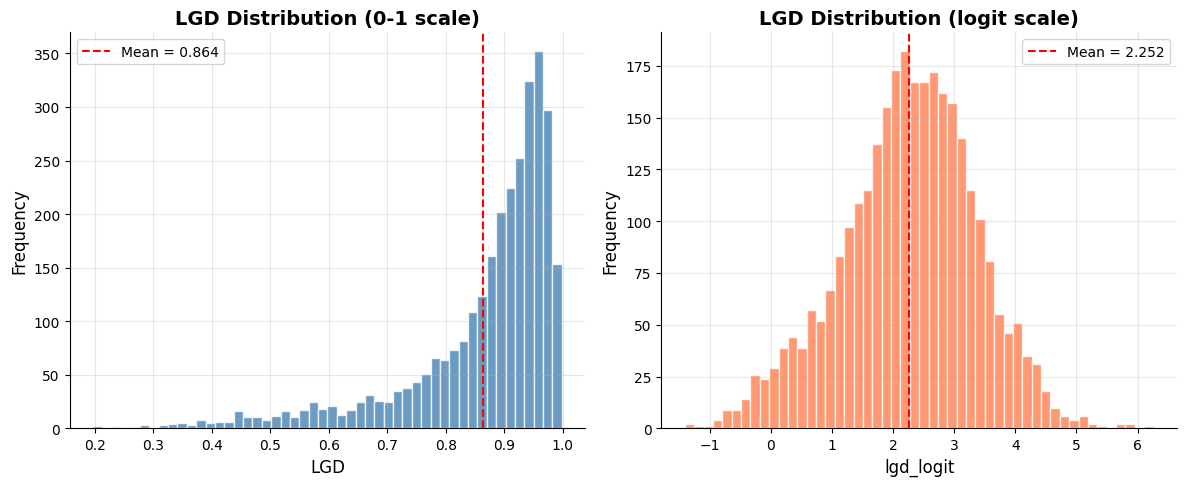

Figure saved.


In [3]:
# Distribution of LGD
df_lgd["lgd"] = expit(df_lgd["lgd_logit"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LGD in [0, 1] scale
axes[0].hist(df_lgd["lgd"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title("LGD Distribution (0-1 scale)", fontweight="bold")
axes[0].set_xlabel("LGD")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
    df_lgd["lgd"].mean(), color="red", linestyle="--", label=f"Mean = {df_lgd['lgd'].mean():.3f}"
)
axes[0].legend()

# LGD in logit scale
axes[1].hist(df_lgd["lgd_logit"], bins=50, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_title("LGD Distribution (logit scale)", fontweight="bold")
axes[1].set_xlabel("lgd_logit")
axes[1].set_ylabel("Frequency")
axes[1].axvline(
    df_lgd["lgd_logit"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {df_lgd['lgd_logit'].mean():.3f}",
)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_lgd_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

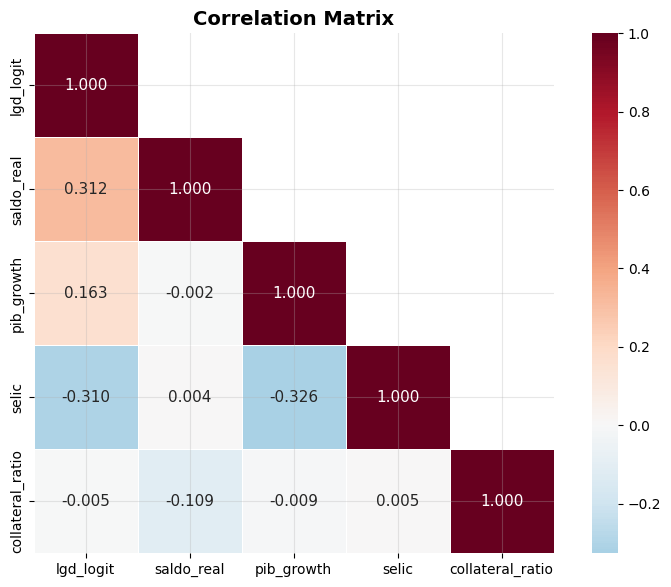

Figure saved.


In [4]:
# Correlation matrix
corr_vars = ["lgd_logit", "saldo_real", "pib_growth", "selic", "collateral_ratio"]
corr_matrix = df_lgd[corr_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

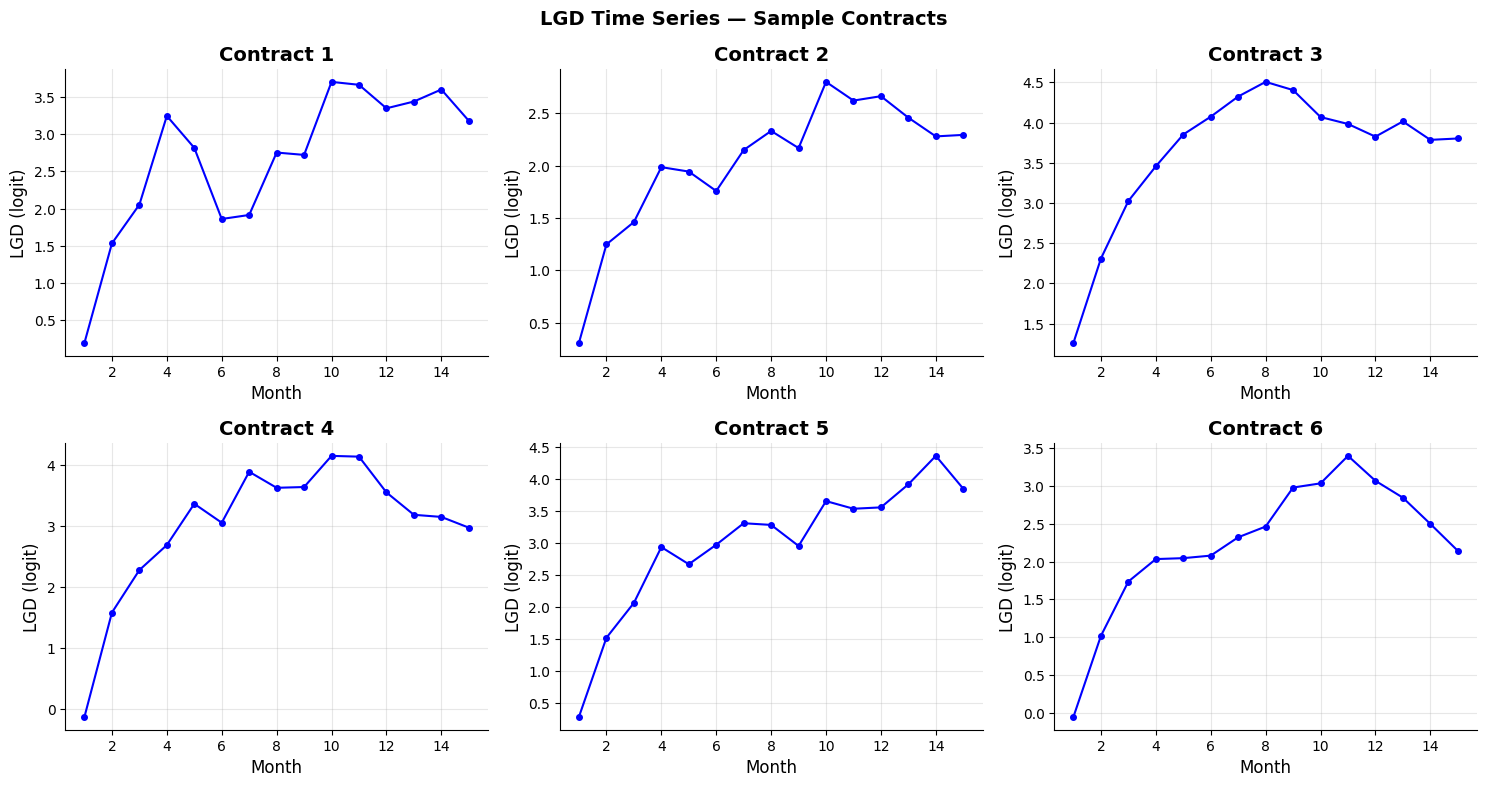

Figure saved.


In [5]:
# Time series plot for sample contracts
sample_contracts = df_lgd["contract_id"].unique()[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cid in enumerate(sample_contracts):
    contract_data = df_lgd[df_lgd["contract_id"] == cid]
    axes[i].plot(contract_data["month"], contract_data["lgd_logit"], "b-o", markersize=4)
    axes[i].set_title(f"Contract {cid}", fontweight="bold")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("LGD (logit)")
    axes[i].grid(alpha=0.3)

plt.suptitle("LGD Time Series — Sample Contracts", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_lgd_time_series.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [6]:
# Missing data check
print("Missing Data Check:")
missing = df_lgd.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  No missing values detected.")
print()

# Panel balance check
obs_per_contract = df_lgd.groupby("contract_id").size()
print(f"Observations per contract: min={obs_per_contract.min()}, max={obs_per_contract.max()}")
if obs_per_contract.min() == obs_per_contract.max():
    print("  Panel is balanced.")
else:
    print("  Panel is unbalanced.")

Missing Data Check:
  No missing values detected.

Observations per contract: min=15, max=15
  Panel is balanced.


---

## Part 3: Model Selection

We compare three approaches:

| Model | Type | Advantages | Disadvantages |
|-------|------|-----------|---------------|
| PooledOLS | Static baseline | Simple, easy to interpret | Ignores dynamics and heterogeneity |
| Fixed Effects | Static with heterogeneity | Controls for contract-specific unobservables | Cannot predict for new contracts |
| Arellano-Bond GMM | Dynamic | Captures LGD persistence, handles endogeneity | More complex, requires instruments |

### Train/Test Split

- **Training**: Months 1-12 (first year of data)
- **Test**: Months 13-15 (last quarter)

In [7]:
# Train/Test split by time
df_train = df_lgd[df_lgd["month"] <= 12].copy()
df_test = df_lgd[df_lgd["month"] > 12].copy()

print(
    f"Training set: {len(df_train)} obs, months {df_train['month'].min()}-{df_train['month'].max()}"
)
print(f"Test set:     {len(df_test)} obs, months {df_test['month'].min()}-{df_test['month'].max()}")
print(f"Contracts in train: {df_train['contract_id'].nunique()}")
print(f"Contracts in test:  {df_test['contract_id'].nunique()}")

Training set: 2400 obs, months 1-12
Test set:     600 obs, months 13-15
Contracts in train: 200
Contracts in test:  200


### Model 1: PooledOLS (Baseline)

In [8]:
# Model 1: PooledOLS
pipe_ols = PanelPipeline(
    model_class=PooledOLS,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD PooledOLS",
)
pipe_ols.fit(df_train)

print("=== PooledOLS ===")
print(pipe_ols.results.summary())

=== PooledOLS ===
                        Pooled OLS Estimation Results                         
Formula: lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio
Model:   Pooled OLS
------------------------------------------------------------------------------
No. Observations:               2,400
No. Entities:                     200
No. Time Periods:                  12
Degrees of Freedom:             2,395
R-squared:                     0.1721
Adj. R-squared:                0.1707
R-squared (overall):           0.1721
Standard Errors:            nonrobust
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
Intercept            4.6979      0.4858   9.670  0.0000    3.7452    5.6505 ***
saldo_real           0.2282      0.0140  16.290  0.0000    0.2007    0.2557 ***
pib_growth           0.0385      0.0097   3.968  0.0001    0.0195    0.0575 ***
selic               -0.5062

### Model 2: Fixed Effects

In [9]:
# Model 2: Fixed Effects
pipe_fe = PanelPipeline(
    model_class=FixedEffects,
    model_params={
        "formula": "lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio",
        "entity_col": "contract_id",
        "time_col": "month",
    },
    name="LGD Fixed Effects",
)
pipe_fe.fit(df_train)

print("=== Fixed Effects ===")
print(pipe_fe.results.summary())

=== Fixed Effects ===
                       Fixed Effects Estimation Results                       
Formula: lgd_logit ~ saldo_real + pib_growth + selic + collateral_ratio
Model:   Fixed Effects
------------------------------------------------------------------------------
No. Observations:               2,400
No. Entities:                     200
No. Time Periods:                  12
Degrees of Freedom:             2,196
R-squared:                     0.1441
Adj. R-squared:                0.0650
R-squared (within):            0.1441
R-squared (between):           1.0000
R-squared (overall):           0.5012
Standard Errors:            nonrobust
F-statistic (FE vs OLS):       7.2816
F-test p-value:                0.0000
Variable        Coef.        Std.Err.     t        P>|t|    [0.025     0.975]    
------------------------------------------------------------------------------
saldo_real           0.0165      0.0595   0.277  0.7818   -0.1002    0.1332 
pib_growth           0.0342    

### Model 3: Arellano-Bond GMM (Dynamic)

In [10]:
# Model 3: Arellano-Bond GMM
pipe_gmm = PanelPipeline(
    model_class=DifferenceGMM,
    model_params={
        "dep_var": "lgd_logit",
        "lags": 1,
        "exog_vars": ["saldo_real", "pib_growth", "selic", "collateral_ratio"],
        "id_var": "contract_id",
        "time_var": "month",
        "gmm_max_lag": 3,
        "collapse": True,
        "two_step": True,
        "robust": True,
        "time_dummies": False,
    },
    name="LGD Arellano-Bond",
)
pipe_gmm.fit(df_train)

print("=== Arellano-Bond GMM ===")
print(pipe_gmm.results.summary())

=== Arellano-Bond GMM ===


                                Difference GMM                                
Number of observations:          2,000
Number of groups:                  200
Number of instruments:               6
Instrument ratio:                0.030
GMM type:                   Two-step (Windmeijer)
------------------------------------------------------------------------------
Variable                    Coef.     Std.Err.        z    P>|z|     [95% Conf. Int.]
------------------------------------------------------------------------------
L1.lgd_logit             0.591334     0.025741    22.97   0.0000 [ 0.540883,  0.641784] ***
saldo_real               0.110943     0.026693     4.16   0.0000 [ 0.058625,  0.163261] ***
pib_growth               0.045573     0.003424    13.31   0.0000 [ 0.038861,  0.052285] ***
selic                   -0.009408     0.014992    -0.63   0.5303 [-0.038792,  0.019976] 
collateral_ratio         0.082015     0.157620     0.52   0.6028 [-0.226914,  0.390944] 
Specification Te

### Out-of-Sample Comparison

In [11]:
# Compare out-of-sample predictions
models = {"PooledOLS": pipe_ols, "Fixed Effects": pipe_fe, "GMM": pipe_gmm}

comparison_results = {}
for name, pipe in models.items():
    preds = pipe.predict(df_test)
    valid = ~np.isnan(preds)

    actual = df_test.loc[valid, "lgd_logit"].values
    pred_valid = preds[valid]

    r = rmse(actual, pred_valid)
    m = mae(actual, pred_valid)
    n_valid = int(valid.sum())

    comparison_results[name] = {
        "RMSE": r,
        "MAE": m,
        "N_valid": n_valid,
    }
    print(f"{name}: RMSE = {r:.4f}, MAE = {m:.4f}, Valid predictions = {n_valid}")

# Model comparison table
comparison_df = pd.DataFrame(comparison_results).T
comparison_df["N_valid"] = comparison_df["N_valid"].astype(int)
print()
print("Model Comparison Table:")
display(comparison_df.round(4))

# Save comparison table
comparison_df.to_csv(TABLES_DIR / "06_model_comparison.csv")
print(f"\nTable saved to {TABLES_DIR / '06_model_comparison.csv'}")

PooledOLS: RMSE = 0.8431, MAE = 0.6726, Valid predictions = 600
Fixed Effects: RMSE = 0.4861, MAE = 0.3887, Valid predictions = 600
GMM: RMSE = 0.4344, MAE = 0.3521, Valid predictions = 400

Model Comparison Table:


,RMSE,MAE,N_valid
PooledOLS,0.8431,0.6726,600
Fixed Effects,0.4861,0.3887,600
GMM,0.4344,0.3521,400



Table saved to ../outputs/tables/06_model_comparison.csv


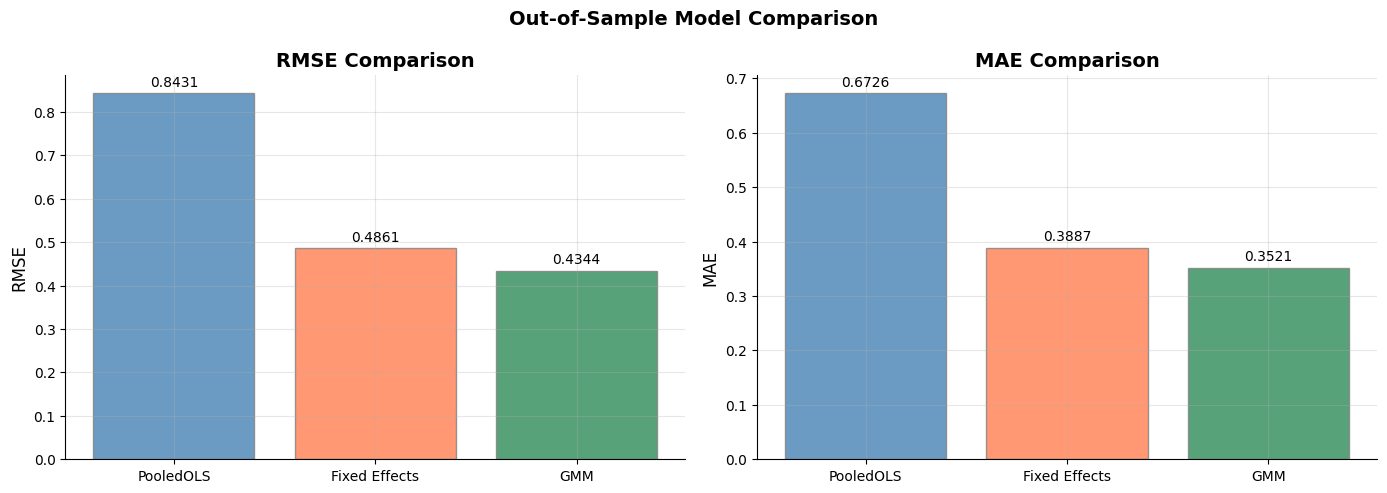

Figure saved.


In [12]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
model_names = list(comparison_results.keys())
rmse_values = [comparison_results[m]["RMSE"] for m in model_names]
mae_values = [comparison_results[m]["MAE"] for m in model_names]

colors = ["steelblue", "coral", "seagreen"]
bars = axes[0].bar(model_names, rmse_values, color=colors, alpha=0.8, edgecolor="gray")
for bar, val in zip(bars, rmse_values):
    axes[0].annotate(
        f"{val:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10,
    )
axes[0].set_title("RMSE Comparison", fontweight="bold")
axes[0].set_ylabel("RMSE")

bars = axes[1].bar(model_names, mae_values, color=colors, alpha=0.8, edgecolor="gray")
for bar, val in zip(bars, mae_values):
    axes[1].annotate(
        f"{val:.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, val),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=10,
    )
axes[1].set_title("MAE Comparison", fontweight="bold")
axes[1].set_ylabel("MAE")

plt.suptitle("Out-of-Sample Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

### Model Selection Discussion

**Trade-offs:**

- **PooledOLS** is the simplest model but ignores LGD dynamics (persistence) and contract-specific effects
- **Fixed Effects** controls for unobserved contract heterogeneity but cannot predict for new contracts that weren't in the training set
- **Arellano-Bond GMM** captures the dynamic persistence of LGD (lag coefficient), handles endogeneity through IV, and can predict for new contracts

For a **production LGD system** where we need to score new contracts monthly, the **GMM model** is the most appropriate because it:
1. Captures the autoregressive nature of LGD (past defaults predict future losses)
2. Can predict for new contracts (unlike FE)
3. Handles potential endogeneity of macro variables

We select the **GMM model** for deployment.

---

## Part 4: Validation Gate

Before deploying any model to production, it must pass a series of validation checks:

1. **Parameter validity** — no NaN or infinite coefficients
2. **Prediction sanity** — predict() runs without error and produces reasonable values
3. **GMM diagnostics** — Hansen J test passes, AR(2) test passes
4. **Business-specific checks** — LGD predictions in reasonable range, drift within tolerance

In [13]:
# Validate the selected model using ModelValidator
selected = pipe_gmm
validator = ModelValidator(selected.results, training_data=df_train)
report = validator.run_all()

print(report["summary"])
print()

if report["passed"]:
    print("Model passed all validation checks -- ready for deployment")
else:
    print("Model FAILED validation -- investigate before deploying")
    for check in report["checks"]:
        if not check.get("passed", True):
            print(f"  FAILED: {check.get('name', 'unknown')}")

Model Validation Report
  parameter_validity: PASSED
  predict_sanity: PASSED
  gmm_diagnostics: PASSED

Model passed all validation checks -- ready for deployment


In [14]:
# Additional business-specific checks
preds_test = selected.predict(df_test)
valid = ~np.isnan(preds_test)
lgd_preds = expit(preds_test[valid])

print("=== Business-Specific Validation ===")
print()

# Check 1: Predictions in reasonable range
print(f"LGD prediction range: [{lgd_preds.min():.4f}, {lgd_preds.max():.4f}]")
assert lgd_preds.min() >= 0, "LGD cannot be negative"
assert lgd_preds.max() <= 1, "LGD cannot exceed 100%"
print("  Range check: PASS (LGD in [0, 1])")
print()

# Check 2: Average LGD within tolerance of historical
historical_avg = expit(df_train["lgd_logit"]).mean()
predicted_avg = lgd_preds.mean()
drift = abs(predicted_avg - historical_avg) / historical_avg * 100
print(f"Historical average LGD: {historical_avg:.4f}")
print(f"Predicted average LGD:  {predicted_avg:.4f}")
print(f"Average LGD drift: {drift:.1f}%")
print(f"  Drift check: {'PASS' if drift < 20 else 'WARNING'} (threshold: 20%)")
print()

# Check 3: Prediction standard deviation
print(f"Prediction std: {lgd_preds.std():.4f}")
print(f"Historical std:  {expit(df_train['lgd_logit']).std():.4f}")

=== Business-Specific Validation ===

LGD prediction range: [0.7799, 0.9920]
  Range check: PASS (LGD in [0, 1])

Historical average LGD: 0.8508
Predicted average LGD:  0.9311
Average LGD drift: 9.4%
  Drift check: PASS (threshold: 20%)

Prediction std: 0.0394
Historical std:  0.1402


In [15]:
# Save validation results
validation_summary = {
    "model_validator_passed": report["passed"],
    "checks": [c.get("name", "unknown") for c in report["checks"]],
    "lgd_range": [float(lgd_preds.min()), float(lgd_preds.max())],
    "historical_avg_lgd": float(historical_avg),
    "predicted_avg_lgd": float(predicted_avg),
    "drift_pct": float(drift),
    "validation_date": datetime.now().isoformat(),
}

val_path = TABLES_DIR / "06_validation_report.csv"
pd.DataFrame([validation_summary]).to_csv(val_path, index=False)
print(f"Validation report saved to {val_path}")

Validation report saved to ../outputs/tables/06_validation_report.csv


---

## Part 5: Deploy to Production

With the model validated, we:
1. Register it in the `ModelRegistry` for versioning and traceability
2. Generate a deployment information package

In [16]:
# Clean the registry directory for a fresh start
import shutil

if REGISTRY_DIR.exists():
    shutil.rmtree(REGISTRY_DIR)
    REGISTRY_DIR.mkdir(parents=True, exist_ok=True)

# Register in model registry
registry = ModelRegistry(REGISTRY_DIR)

# Compute test RMSE for notes
preds_test_valid = preds_test[valid]
actual_test_valid = df_test.loc[valid, "lgd_logit"].values
rmse_test = rmse(actual_test_valid, preds_test_valid)

version = registry.register(
    selected,
    notes=f"Initial production model. Arellano-Bond GMM with collapse, 2-step. RMSE={rmse_test:.4f} on test set.",
)
print(f"Registered as: {version}")
print()

# Show registry status
print("Registry versions:")
for v in registry.list_versions():
    print(f"  {v['version']}: {v['notes'][:80]}...")

Registered as: v1

Registry versions:
  v1: Initial production model. Arellano-Bond GMM with collapse, 2-step. RMSE=0.4344 o...


In [17]:
# Generate deployment package
deployment_info = {
    "model_name": "LGD_PROD_V1",
    "model_type": "Arellano-Bond GMM",
    "trained_on": "bank_lgd.csv months 1-12",
    "validated_on": "bank_lgd.csv months 13-15",
    "rmse_test": float(rmse_test),
    "coefficients": selected.results.params.to_dict(),
    "deployment_date": datetime.now().isoformat(),
    "next_review": "Quarterly",
    "validation_passed": report["passed"],
}

deploy_path = MODELS_DIR / "lgd_deployment_info.json"
deploy_path.write_text(json.dumps(deployment_info, indent=2))

print(f"Deployment info saved to {deploy_path}")
print()
print("Deployment package:")
print(json.dumps(deployment_info, indent=2))

Deployment info saved to ../outputs/models/lgd_deployment_info.json

Deployment package:
{
  "model_name": "LGD_PROD_V1",
  "model_type": "Arellano-Bond GMM",
  "trained_on": "bank_lgd.csv months 1-12",
  "validated_on": "bank_lgd.csv months 13-15",
  "rmse_test": 0.43436182657517775,
  "coefficients": {
    "L1.lgd_logit": 0.5913339338972379,
    "saldo_real": 0.11094311762945554,
    "pib_growth": 0.04557288789885184,
    "selic": -0.009408163723253454,
    "collateral_ratio": 0.08201515968446088
  },
  "deployment_date": "2026-02-22T16:09:50.703737",
  "next_review": "Quarterly",
  "validation_passed": true
}


---

## Part 6: Production Simulation

Simulate 3 months of production use, scoring new contracts each month with the deployed model.

In [18]:
# Load the latest model from the registry (simulating production)
production_pipeline = registry.load_latest()
print(f"Loaded production model: {production_pipeline.name}")
print(f"Fitted at: {production_pipeline.fit_timestamp}")
print()

# Simulate 3 months of production use
# Note: GMM predict() needs lag data. We predict on cumulative data
# and extract the current month's results.
production_log = []

for month_offset in range(1, 4):
    # In production, we score using all available data up to current month
    # so that lagged dependent variable is available
    cumulative_data = df_new_bank[df_new_bank["month"] <= month_offset].copy()

    if len(cumulative_data) == 0:
        print(f"\nMonth {month_offset}: No data available, skipping.")
        continue

    # Generate predictions on cumulative data
    preds = production_pipeline.predict(cumulative_data)

    # Extract predictions for current month only
    current_month_mask = cumulative_data["month"] == month_offset
    preds_current = preds[current_month_mask.values]
    valid = ~np.isnan(preds_current)

    if valid.sum() == 0:
        print(f"\nMonth {month_offset}:")
        print(f"  Contracts scored: {current_month_mask.sum()}")
        print("  Valid predictions: 0 (first month — no lag available for GMM)")
        production_log.append(
            {
                "month": month_offset,
                "n_contracts": int(current_month_mask.sum()),
                "n_valid": 0,
                "avg_lgd": np.nan,
                "min_lgd": np.nan,
                "max_lgd": np.nan,
            }
        )
        continue

    lgd = expit(preds_current[valid])

    print(f"\nMonth {month_offset}:")
    print(f"  Contracts scored: {current_month_mask.sum()}")
    print(f"  Valid predictions: {valid.sum()}")
    print(f"  Average LGD: {lgd.mean():.4f}")
    print(f"  Min/Max LGD: {lgd.min():.4f} / {lgd.max():.4f}")

    # Check for anomalies
    if lgd.mean() > 0.8:
        print("  WARNING: Average LGD unusually high!")
    elif lgd.mean() < 0.1:
        print("  WARNING: Average LGD unusually low!")
    else:
        print("  Status: Normal range")

    production_log.append(
        {
            "month": month_offset,
            "n_contracts": int(current_month_mask.sum()),
            "n_valid": int(valid.sum()),
            "avg_lgd": float(lgd.mean()),
            "min_lgd": float(lgd.min()),
            "max_lgd": float(lgd.max()),
        }
    )

# Production log
print("\n=== Production Log ===")
prod_log_df = pd.DataFrame(production_log)
display(prod_log_df.round(4))

prod_log_df.to_csv(TABLES_DIR / "06_production_log.csv", index=False)
print(f"\nProduction log saved to {TABLES_DIR / '06_production_log.csv'}")

Loaded production model: LGD Arellano-Bond
Fitted at: 2026-02-22T16:09:50.193212


Month 1:
  Contracts scored: 50
  Valid predictions: 0 (first month — no lag available for GMM)

Month 2:
  Contracts scored: 50
  Valid predictions: 50
  Average LGD: 0.7363
  Min/Max LGD: 0.5094 / 0.8988
  Status: Normal range

Month 3:
  Contracts scored: 50
  Valid predictions: 50
  Average LGD: 0.8344
  Min/Max LGD: 0.6262 / 0.9425

=== Production Log ===


,month,n_contracts,n_valid,avg_lgd,min_lgd,max_lgd
0,1,50,0,NaN,NaN,NaN
1,2,50,50,0.7363,0.5094,0.8988
2,3,50,50,0.8344,0.6262,0.9425



Production log saved to ../outputs/tables/06_production_log.csv


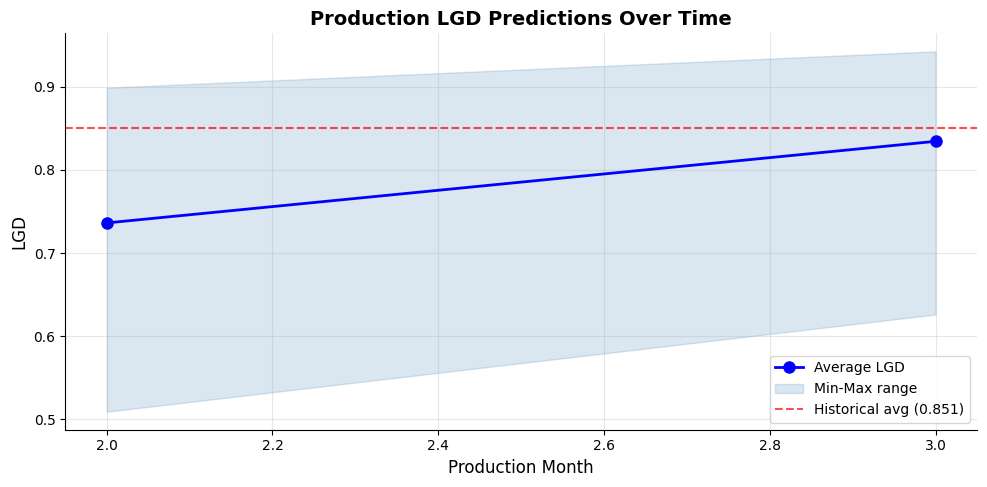

Figure saved.


In [19]:
# Visualize production predictions over time (exclude months with no valid predictions)
prod_log_valid = prod_log_df.dropna(subset=["avg_lgd"])

fig, ax = plt.subplots(figsize=(10, 5))

if len(prod_log_valid) > 0:
    months = prod_log_valid["month"].values
    avg_lgd = prod_log_valid["avg_lgd"].values
    min_lgd = prod_log_valid["min_lgd"].values
    max_lgd = prod_log_valid["max_lgd"].values

    ax.plot(months, avg_lgd, "b-o", linewidth=2, markersize=8, label="Average LGD")
    ax.fill_between(months, min_lgd, max_lgd, alpha=0.2, color="steelblue", label="Min-Max range")

ax.axhline(
    y=historical_avg,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Historical avg ({historical_avg:.3f})",
)

ax.set_xlabel("Production Month")
ax.set_ylabel("LGD")
ax.set_title("Production LGD Predictions Over Time", fontweight="bold", fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_production_monitoring.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

---

## Part 7: Quarterly Re-estimation

After 3 months of production use, we re-estimate the model with all available data (original + new) and check for coefficient drift.

In [20]:
# Combine all available data
df_all = pd.concat([df_lgd, df_new_bank], ignore_index=True)
print(f"Combined data: {len(df_all)} observations")
print(f"Contracts: {df_all['contract_id'].nunique()}")
print(f"Months: {df_all['month'].nunique()}")
print()

# Load the current production model
old_pipeline = registry.load_latest()
print(f"Current production model: {old_pipeline.name}")
print("Current coefficients:")
print(old_pipeline.results.params)
print()

Combined data: 3150 observations
Contracts: 200
Months: 15

Current production model: LGD Arellano-Bond
Current coefficients:
L1.lgd_logit        0.5913
saldo_real          0.1109
pib_growth          0.0456
selic              -0.0094
collateral_ratio    0.0820
dtype: float64



In [21]:
# Re-estimate with all available data
new_pipeline = PanelPipeline(
    model_class=DifferenceGMM,
    model_params=pipe_gmm.model_params.copy(),
    name="LGD Arellano-Bond v2",
)
new_pipeline.fit(df_all)

print("New model coefficients:")
print(new_pipeline.results.params)
print()

New model coefficients:
L1.lgd_logit        0.5792
saldo_real          0.0890
pib_growth          0.0441
selic              -0.0131
collateral_ratio    0.1459
dtype: float64



In [22]:
# Compare old vs new (drift analysis)
drift_report = new_pipeline.compare(old_pipeline)

print("Coefficient Drift Report:")
print("=" * 65)
display(drift_report.round(4))

# Identify significant changes
significant = drift_report[drift_report["pct_change"].abs() > 10]
if len(significant) > 0:
    print("\nParameters with >10% change:")
    display(significant.round(4))
else:
    print("\nNo parameters with >10% change -- model is stable.")

# Save drift report
drift_report.to_csv(TABLES_DIR / "06_drift_report.csv")
print(f"\nDrift report saved to {TABLES_DIR / '06_drift_report.csv'}")

Coefficient Drift Report:


,current,previous,diff,pct_change
L1.lgd_logit,0.5792,0.5913,-0.0122,-2.0569
saldo_real,0.0890,0.1109,-0.0220,-19.7982
pib_growth,0.0441,0.0456,-0.0015,-3.1982
selic,-0.0131,-0.0094,-0.0037,-38.8047
collateral_ratio,0.1459,0.0820,0.0639,77.9528



Parameters with >10% change:


,current,previous,diff,pct_change
saldo_real,0.0890,0.1109,-0.0220,-19.7982
selic,-0.0131,-0.0094,-0.0037,-38.8047
collateral_ratio,0.1459,0.0820,0.0639,77.9528



Drift report saved to ../outputs/tables/06_drift_report.csv


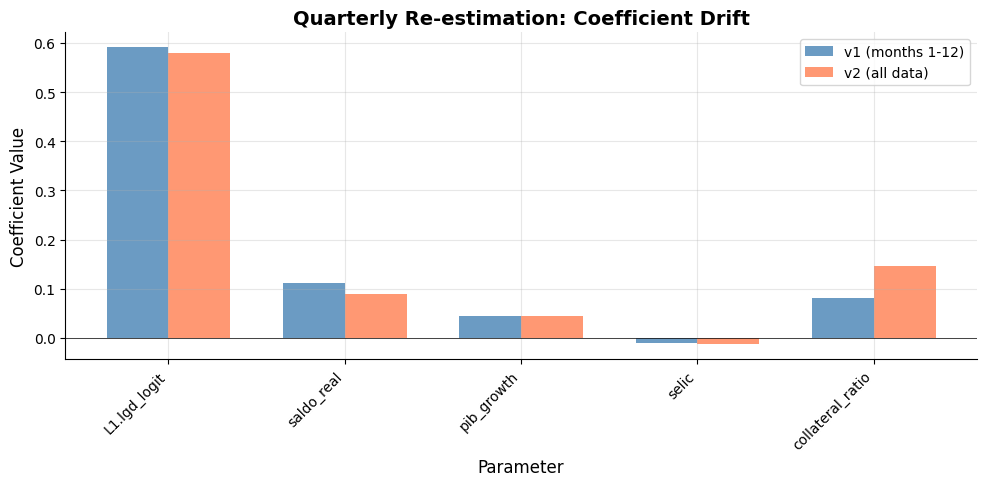

Figure saved.


In [23]:
# Visualize coefficient drift
fig, ax = plt.subplots(figsize=(10, 5))

params = drift_report.index
x = np.arange(len(params))
width = 0.35

ax.bar(
    x - width / 2,
    drift_report["previous"],
    width,
    label="v1 (months 1-12)",
    color="steelblue",
    alpha=0.8,
)
ax.bar(
    x + width / 2, drift_report["current"], width, label="v2 (all data)", color="coral", alpha=0.8
)

ax.set_xlabel("Parameter")
ax.set_ylabel("Coefficient Value")
ax.set_title("Quarterly Re-estimation: Coefficient Drift", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(params, rotation=45, ha="right")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.axhline(y=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_quarterly_drift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [24]:
# Validate the new model and register if it passes
new_report = new_pipeline.validate()

print(f"New model validation: {'PASS' if new_report['passed'] else 'FAIL'}")
for check in new_report["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"  [{status}] {check['name']}")

if new_report["passed"]:
    v2 = registry.register(
        new_pipeline,
        notes="Quarterly update with new data. All diagnostics pass.",
    )
    print(f"\nNew version registered: {v2}")
else:
    print("\nValidation failed -- keeping current production version.")

# Show all versions
print("\nAll registered versions:")
for v in registry.list_versions():
    print(f"  {v['version']}: {v['model_class']} — {v['notes'][:60]}...")

New model validation: FAIL
  [PASS] has_params
  [PASS] no_nan_params
  [PASS] hansen_j_valid
  [FAIL] ar2_valid
  [PASS] instrument_ratio_ok

Validation failed -- keeping current production version.

All registered versions:
  v1: DifferenceGMM — Initial production model. Arellano-Bond GMM with collapse, 2...


---

## Part 8: Final Summary and Report

### Complete Workflow Summary

```
EDA → Model Selection → Validation Gate → Deploy → Monitor → Quarterly Refit
```

| Step | Tools Used | Output |
|------|-----------|--------|
| **EDA** | pandas, matplotlib | Distribution plots, correlation matrix |
| **Model Selection** | PanelPipeline (OLS, FE, GMM) | RMSE/MAE comparison table |
| **Validation** | ModelValidator, business checks | Validation report |
| **Deployment** | ModelRegistry | Versioned model + deployment JSON |
| **Monitoring** | PanelPipeline.predict() | Monthly prediction logs |
| **Re-estimation** | PanelPipeline.compare() | Drift report, new version |

In [25]:
# Final summary metrics
print("=== LGD Production System — Final Report ===")
print()
print("Selected model: Arellano-Bond GMM (2-step, collapsed instruments)")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test MAE:  {comparison_results['GMM']['MAE']:.4f}")
print()
print("Coefficients (production v1):")
for param, value in selected.results.params.items():
    print(f"  {param:25s} {value:>10.4f}")
print()
print("GMM Diagnostics:")
print(f"  Hansen J p-value: {selected.results.hansen_j.pvalue:.4f}")
print(f"  AR(2) p-value:    {selected.results.ar2_test.pvalue:.4f}")
print(f"  Instrument ratio: {selected.results.instrument_ratio:.3f}")
print()
print("Model versions in registry:", len(registry.list_versions()))
print()
print("Recommendations:")
print("  1. Schedule quarterly re-estimation with expanding training window")
print("  2. Monitor average LGD drift monthly (threshold: 20%)")
print("  3. Set up automated alerts for prediction range violations")
print("  4. Archive all model versions for regulatory audit trail")

=== LGD Production System — Final Report ===

Selected model: Arellano-Bond GMM (2-step, collapsed instruments)
Test RMSE: 0.4344
Test MAE:  0.3521

Coefficients (production v1):
  L1.lgd_logit                  0.5913
  saldo_real                    0.1109
  pib_growth                    0.0456
  selic                        -0.0094
  collateral_ratio              0.0820

GMM Diagnostics:
  Hansen J p-value: 0.1227
  AR(2) p-value:    0.1138
  Instrument ratio: 0.030

Model versions in registry: 1

Recommendations:
  1. Schedule quarterly re-estimation with expanding training window
  2. Monitor average LGD drift monthly (threshold: 20%)
  3. Set up automated alerts for prediction range violations
  4. Archive all model versions for regulatory audit trail


---

## Exercises

### Exercise 1 (Easy): Add Random Effects Model

Add a `RandomEffects` model to the comparison in Part 3.

1. Create a `PanelPipeline` with `RandomEffects` and the same formula
2. Fit on `df_train`, predict on `df_test`
3. Compute RMSE and MAE
4. Does it improve over PooledOLS?

In [26]:
# Exercise 1: Your code here


### Exercise 2 (Medium): GMM Forecasting

Use the GMM model's `forecast()` method to predict LGD 3 months ahead for 5 contracts.

1. Select 5 contracts from `df_train`
2. Build `last_obs` dictionary with the last observed lgd_logit value per contract
3. Build `future_exog` DataFrame with assumed macro values for 3 months ahead
4. Generate forecasts and compare with actual values from `df_test`
5. Plot the forecast trajectory alongside the actual values

In [27]:
# Exercise 2: Your code here


### Exercise 3 (Hard): Backtesting Framework

Build a complete backtesting framework:

1. Use expanding window: train on months 1-8, predict month 9; train on 1-9, predict 10; etc.
2. For each window, re-estimate the GMM model and save predictions
3. Compute cumulative RMSE over time
4. Plot the backtesting results
5. Identify if model performance degrades over time

In [28]:
# Exercise 3: Your code here


### Exercise 4 (Expert): Automated Production Script

Create an automated production script (as a Python function here) that:

1. Reads configuration from a JSON dictionary
2. Loads data from a CSV path
3. Loads the latest model from the registry
4. Generates predictions
5. Runs validation checks (LGD range, drift)
6. Saves results to a CSV
7. Logs everything

In a real production system, this would be a standalone `.py` script called by a scheduler (cron, Airflow, etc.).

In [29]:
# Exercise 4: Your code here


---

*Solutions are available in `../solutions/06_case_study_bank_lgd_solutions.ipynb`*